# Aula 01 — De DN para reflectância (TOA e BOA) e fusão com a pancromática

Pegamos os recortes em **números digitais** que a Aula 00 gravou em `data/raw` e saímos daqui
com uma imagem de **2 m em reflectância de superfície**, pronta para a detecção de nuvem
(Aula 02) e para a substituição de pixels com Sentinel-2 (Aula 03).

O caminho tem quatro trechos:

| etapa | de | para | onde acontece |
|---|---|---|---|
| calibração radiométrica | DN | radiância (W m⁻² sr⁻¹ µm⁻¹) | bandas MS de 8 m |
| reflectância TOA | radiância | ρ no topo da atmosfera | bandas MS de 8 m |
| correção atmosférica (6S) | ρ TOA | ρ de superfície (BOA) | bandas MS de 8 m |
| fusão Gram-Schmidt | MS 8 m + PAN 2 m | RGBN de 2 m | grade da pancromática |

**A ordem importa.** A conversão é feita nas bandas MS **nativas de 8 m, antes da fusão**.
A fusão redistribui valores entre as bandas e não preserva a linearidade radiométrica banda a
banda; aplicar coeficientes de calibração MS sobre um produto já fusionado seria uma
aproximação. Convertendo antes, a fusão passa a operar em espaço de reflectância.

> Isso **não** torna a fusão radiometricamente rigorosa — o Gram-Schmidt continua sem preservar
> exatamente a resposta espectral. O que muda é que as entradas passam a ser fisicamente válidas.

**Por que ir até BOA e não parar no TOA?** Porque na Aula 03 vamos colar pedaços de
Sentinel-2 dentro desta imagem, e o produto Sentinel-2 L2A é reflectância **de superfície**.
Comparar e harmonizar duas imagens no mesmo nível é muito mais honesto do que corrigir a
diferença depois, no ajuste empírico.

> **Trilha recomendada:** rode local, com `pixi run lab`. O ambiente do projeto já traz o Py6S e
> o executável do 6S. No Colab a correção BOA também roda, mas exige instalar o conda dentro da
> sessão — funciona, e às vezes dá trabalho. As duas trilhas estão logo abaixo.

## Preparando o ambiente

A célula seguinte detecta onde você está. **No pixi local ela não faz nada** — o ambiente já
tem tudo. **No Colab** ela instala o `condacolab`, que é o que permite trazer o executável do
6S (um programa em Fortran, que não existe no PyPI).

> No Colab, esta célula **reinicia a sessão**. Isso é normal: espere a mensagem de reinício e
> siga para a célula seguinte. Não rode as duas de uma vez.

In [ ]:
# --- Colab, parte 1 de 2: instala o conda na sessão (REINICIA o ambiente) ---
import sys

NO_COLAB = "google.colab" in sys.modules
print("Ambiente:", "Google Colab" if NO_COLAB else "local (pixi/Jupyter)")

if NO_COLAB:
    !pip install -q condacolab
    import condacolab
    condacolab.install()   # o ambiente reinicia aqui — é esperado

In [ ]:
# --- Colab, parte 2 de 2: rode DEPOIS do reinício ---
import sys

NO_COLAB = "google.colab" in sys.modules
if NO_COLAB:
    # rasterio pelo conda-forge junto com o 6S: misturar o GDAL do pip com o do
    # conda é a origem mais comum de erro difícil de diagnosticar.
    !mamba install -q -y -c conda-forge rasterio pyproj py6s sixs pystac-client requests
    print("pronto")

In [1]:
# --- Traz o módulo de apoio e os arquivos de configuração do repositório ---
# aulas_cbers.py guarda, de forma compacta, as etapas das aulas anteriores; é o
# que permite começar o curso por qualquer aula. config/ traz a ESUN do sensor e
# os parâmetros atmosféricos.
import os
from pathlib import Path

REPO = "https://github.com/danfioramonte/geoprocessamento-cbers4a"

if not Path("aulas_cbers.py").exists():
    !git clone -q --depth 1 {REPO} /tmp/geo_repo
    !cp /tmp/geo_repo/colab/aulas_cbers.py .
    !cp -r /tmp/geo_repo/colab/config .

for alvo in ["aulas_cbers.py", "config/esun_wpm.json", "config/atmosfera_rio_claro.json"]:
    print(("ok  " if Path(alvo).exists() else "FALTA"), alvo)

ok   aulas_cbers.py
ok   config/esun_wpm.json
ok   config/atmosfera_rio_claro.json


## 0. Configuração

Um único lugar para mexer. `CENA_ID` é o identificador que a Aula 00 usou para nomear os
arquivos em `data/raw`; se você escolheu outra cena lá, troque aqui.

`AOI_BBOX` **precisa ser o mesmo das outras aulas**. Todo o curso trabalha na mesma janela, e
é isso que faz o coregistro do AROSICS fechar na Aula 03.

In [2]:
import aulas_cbers as ac

ac.configurar_gdal()          # ajustes de leitura remota, ANTES do rasterio

import json
import math
from datetime import date, datetime

import matplotlib.pyplot as plt
import numpy as np
import rasterio
from rasterio.enums import ColorInterp, Resampling
from rasterio.warp import reproject

# ---- parâmetros da aula -----------------------------------------------------
CENA_ID = ac.CENA_PADRAO          # cena de referência do curso (Rio Claro, com nuvem)
AOI_BBOX = ac.AOI_BBOX            # [oeste, sul, leste, norte] em EPSG:4326
NIVEL = "boa"                     # "boa" (recomendado) ou "toa"
ESCALA = ac.ESCALA                # reflectância 0-1 gravada como int16 x10000
NODATA = ac.NODATA                # -9999

# Faixa física da reflectância GRAVADA. Reflectância negativa não existe na
# natureza: o que aparece abaixo de zero é ruído da correção atmosférica e
# undershoot da fusão sobre alvo escuro. O diagnóstico da seção 4.3 mede esses
# negativos ANTES de gravar — o piso não esconde o sintoma, só evita que o
# produto final carregue valor impossível. Como o NODATA é -9999, pixel ceifado
# continua VÁLIDO (vale 0), não vira buraco.
PISO_REFLECTANCIA = 0.0
TETO_REFLECTANCIA = 1.6

# Busca do AOD pelo critério do alvo escuro (seção 4.1). Custa ~30 s e evita o
# erro mais comum do BOA: corrigir demais e afundar a cena em valores negativos.
AJUSTAR_AOD = True

# No Colab, para não perder tudo quando a sessão encerrar, monte o Drive e
# aponte a base para lá:
#   from google.colab import drive; drive.mount('/content/drive')
#   ac.definir_base('/content/drive/MyDrive/geoproc/data')
P = ac.pastas()
DATA = ac.data_da_cena(CENA_ID)

print(f"cena  : {CENA_ID}")
print(f"data  : {DATA}")
print(f"nível : {NIVEL.upper()}")
print(f"bbox  : {AOI_BBOX}")
print(f"dados : {P['base'].resolve()}")

cena  : CBERS_4A_WPM_20260301_203_141_L4
data  : 20260301
nível : BOA
bbox  : [-47.596712, -22.467523, -47.495068, -22.374216]
dados : C:\geo\geoprocessamento-cbers4a\colab\data


## 1. As bandas da cena

Se você fez a Aula 00, os arquivos já estão em `data/raw`. Se pulou direto para cá, a célula
abaixo baixa os mesmos recortes do STAC do INPE — mesma cena, mesmo bbox.

In [3]:
arquivos = ac.arquivos_da_cena(CENA_ID)
if len(arquivos) < 5:
    arquivos = ac.preparar_aula_01(CENA_ID)

for asset in ["BAND1", "BAND2", "BAND3", "BAND4", "BAND0"]:
    with rasterio.open(arquivos[asset]) as src:
        print(f"{asset} ({ac.BANDAS[asset]:>5}): {src.width:>5} x {src.height:<5} px "
              f"@ {src.res[0]:g} m | {src.dtypes[0]} | nodata={src.nodata} | {src.crs}")

BAND1 ( blue):  1287 x 1314  px @ 8 m | int16 | nodata=0.0 | EPSG:32723
BAND2 (green):  1287 x 1314  px @ 8 m | int16 | nodata=0.0 | EPSG:32723
BAND3 (  red):  1287 x 1314  px @ 8 m | int16 | nodata=0.0 | EPSG:32723
BAND4 (  nir):  1287 x 1314  px @ 8 m | int16 | nodata=0.0 | EPSG:32723
BAND0 (  pan):  5146 x 5257  px @ 2 m | int16 | nodata=0.0 | EPSG:32723


## 2. O que o XML de metadados traz

Ao lado de cada banda, a Aula 00 baixou o XML do produto. É de lá que vem tudo o que a física
da conversão precisa:

- **`absoluteCalibrationCoefficient`** — um ganho por banda, que transforma DN em radiância;
- **`sunPosition/elevation`** — a elevação do Sol no momento da passagem;
- a **data** da passagem, que dá a distância Terra-Sol.

A convenção do coeficiente é **multiplicativa e sem offset**:

$$L = DN \times \text{coeficiente}$$

Pinto et al. (2016) confirmam a forma $L = G \cdot DN + b$ para os sensores CBERS e mostram que
todos os interceptos ajustados são estatisticamente consistentes com zero. Fisicamente faz
sentido: sem energia incidente, a resposta esperada é zero. O XML do WPM, coerentemente, traz
só o ganho.

In [4]:
meta = ac.ler_xml(CENA_ID)
esun = ac.ler_esun()          # config/esun_wpm.json (fonte: CRESDA, anexo 4)

quando = date.fromisoformat(meta["data"])
d = ac.distancia_terra_sol(quando)
cos_z = math.cos(math.radians(meta["zenite_solar"]))

print(f"XML             : {Path(meta['xml']).name}")
print(f"data/hora       : {meta['datahora']}")
print(f"órbita/ponto    : {meta['orbita']}/{meta['ponto']}  (nível {meta['nivel_produto']})")
print(f"elevação solar  : {meta['elevacao_solar']:.4f}°")
print(f"zênite solar    : {meta['zenite_solar']:.4f}°  (cos = {cos_z:.5f})")
print(f"distância T-S   : {d:.5f} UA")
print(f"pixel           : {meta['pixel_m']:.1f} m\n")
print(f"{'banda':<10} {'coef. calib.':>14} {'ESUN (W m-2 um-1)':>20}")
for n, nome in ac.BANDAS_NATIVAS.items():
    print(f"{n} {nome:<8} {meta['coeficientes'][n]:>14.6f} {esun[n]:>20.2f}")

XML             : rio_claro_CBERS_4A_WPM_20260301_203_141_L4_BAND0.xml
data/hora       : 2026-03-01T13:03:19.194000
órbita/ponto    : 203/141  (nível 4)
elevação solar  : 54.4088°
zênite solar    : 35.5912°  (cos = 0.81319)
distância T-S   : 0.99045 UA
pixel           : 2.0 m

banda        coef. calib.    ESUN (W m-2 um-1)
1 azul           0.291070              1939.89
2 verde          0.297832              1847.82
3 vermelho       0.232504              1535.15
4 nir            0.178993              1071.41


## 3. DN → radiância → reflectância TOA

Duas contas, uma atrás da outra:

$$L_\lambda = DN \times G_\lambda \qquad\qquad
\rho_{TOA} = \frac{\pi \, d^2 \, L_\lambda}{ESUN_\lambda \, \cos\theta_z}$$

onde $d$ é a distância Terra-Sol em UA e $\theta_z$ é o ângulo zenital solar (90° menos a
elevação). O $ESUN$ é a irradiância solar exoatmosférica da banda — vem do arquivo de
configuração, derivado da resposta espectral real do WPM pela CRESDA.

**Nodata.** O produto usa 0 para "sem dado". Marcamos como nodata o pixel que vale zero em
**qualquer** banda, e não só o que vale zero em todas. A razão é física: em reflectância TOA o
azul nunca é zero sobre a terra, porque a radiância de trajetória do espalhamento Rayleigh
garante sinal até dentro de sombra profunda. Um zero isolado, portanto, é artefato de borda da
faixa imageada — e se ficar como válido, entra na fusão deformando a estatística por banda.

In [5]:
dn, perfil, forma = {}, None, None
for n in sorted(ac.BANDAS_NATIVAS):
    with rasterio.open(arquivos[f"BAND{n}"]) as src:
        if perfil is None:
            perfil, forma = src.profile.copy(), (src.height, src.width)
        elif (src.height, src.width) != forma:
            raise ValueError("as bandas MS não estão na mesma grade")
        dn[n] = src.read(1)

zeros = np.zeros(forma, dtype=bool)
simultaneos = np.ones(forma, dtype=bool)
for n in dn:
    zeros |= (dn[n] == 0)
    simultaneos &= (dn[n] == 0)
valido = ~zeros

print(f"grade MS : {forma[1]} x {forma[0]} px")
print(f"nodata   : {zeros.sum():,} px ({zeros.mean():.2%})")
print(f"  zero em todas as bandas : {int(simultaneos.sum()):,}")
print(f"  zero em algumas bandas  : {int((zeros & ~simultaneos).sum()):,}  "
      f"(marcados como nodata)")

# ---- a conversão propriamente dita ----
radiancia, toa = {}, {}
for n, nome in ac.BANDAS_NATIVAS.items():
    radiancia[n] = ac.dn_para_radiancia(dn[n], meta["coeficientes"][n])
    toa[n] = ac.radiancia_para_toa(radiancia[n], esun[n], d, cos_z)

for n, nome in ac.BANDAS_NATIVAS.items():
    v = toa[n][valido]
    print(f"{nome:<9} TOA: p1={np.percentile(v, 1):.4f}  p50={np.percentile(v, 50):.4f}  "
          f"p99={np.percentile(v, 99):.4f}  máx={v.max():.4f}")

grade MS : 1287 x 1314 px
nodata   : 21 px (0.00%)
  zero em todas as bandas : 0
  zero em algumas bandas  : 21  (marcados como nodata)
azul      TOA: p1=0.0836  p50=0.1024  p99=0.2877  máx=0.5817
verde     TOA: p1=0.0629  p50=0.0959  p99=0.2834  máx=0.6249
vermelho  TOA: p1=0.0425  p50=0.0798  p99=0.3019  máx=0.5872
nir       TOA: p1=0.0836  p50=0.2412  p99=0.4096  máx=0.6477


### Conferindo antes de seguir

Vale gastar trinta segundos aqui. Se a convenção do coeficiente estivesse invertida (divisiva
em vez de multiplicativa), a reflectância na saturação passaria de 1,0 na maioria dos pixels —
fisicamente impossível. E se o vermelho e o NIR estivessem trocados, o NDVI ficaria negativo
sobre vegetação.

Faixas esperadas em TOA:

| alvo | vermelho | NIR | NDVI |
|---|---|---|---|
| vegetação densa | 0,03–0,10 | 0,20–0,45 | 0,45–0,80 |
| solo exposto | próximos entre si | próximos entre si | 0,05–0,25 |
| água | — | < 0,06 | negativo |

In [6]:
def sanidade(refl_por_nome, valido, n_amostra=200_000):
    """Faixas de reflectância e NDVI numa amostra de pixels válidos."""
    idx = np.flatnonzero(valido.ravel())
    if idx.size > n_amostra:
        idx = np.random.default_rng(42).choice(idx, n_amostra, replace=False)
    pct = [1, 5, 50, 95, 99]
    print(f"{'banda':<10} " + " ".join(f"p{p:<7}" for p in pct) + "  frac>1")
    for nome, arr in refl_por_nome.items():
        v = arr.ravel()[idx]
        linha = " ".join(f"{x:<8.4f}" for x in np.percentile(v, pct))
        print(f"{nome:<10} {linha}  {float((v > 1.0).mean()):.4%}")

    r = refl_por_nome["vermelho"].ravel()[idx]
    nir = refl_por_nome["nir"].ravel()[idx]
    den = nir + r
    ndvi = np.where(den > 1e-6, (nir - r) / np.where(den > 1e-6, den, 1), np.nan)
    ndvi = ndvi[np.isfinite(ndvi)]
    print(f"{'NDVI':<10} " + " ".join(f"{x:<8.4f}" for x in np.percentile(ndvi, pct)))

    p95 = float(np.percentile(ndvi, 95))
    if p95 < 0.35:
        print("\n  > NDVI p95 baixo demais para uma cena com vegetação. "
              "Confira a atribuição vermelho/NIR.")
    elif p95 > 0.95:
        print("\n  > NDVI p95 alto demais. Confira os valores de ESUN.")
    else:
        print("\n  > faixas dentro do esperado.")


sanidade({ac.BANDAS_NATIVAS[n]: toa[n] for n in sorted(toa)}, valido)

banda      p1       p5       p50      p95      p99       frac>1
azul       0.0836   0.0864   0.1024   0.1820   0.2855    0.0000%
verde      0.0629   0.0684   0.0959   0.1802   0.2810    0.0000%
vermelho   0.0425   0.0471   0.0798   0.2118   0.3013    0.0000%
nir        0.0836   0.1285   0.2406   0.3495   0.4090    0.0000%
NDVI       -0.0218  0.0527   0.4865   0.7033   0.7413  

  > faixas dentro do esperado.


## 4. TOA → BOA: a correção atmosférica com o 6S

A reflectância TOA inclui o que a atmosfera fez com a luz no caminho: espalhamento (que
acrescenta brilho, sobretudo no azul), absorção por vapor d'água e ozônio (que tira), e o
efeito de vizinhança. O **6S** modela isso e devolve três coeficientes por banda, que invertem
a relação:

$$y = x_a L - x_b \qquad\qquad \rho_{BOA} = \frac{y}{1 + x_c \, y}$$

Os coeficientes dependem da geometria (Sol e sensor), da altitude do alvo e do estado da
atmosfera no dia: **AOD em 550 nm**, **coluna de vapor d'água** e **coluna de ozônio**. Esses
três números ficam em `config/atmosfera_rio_claro.json`.

> **Leia o aviso dentro do JSON.** Os valores que deixei ali são padrões plausíveis para o
> verão do interior paulista, **não medidas do dia da cena**. Servem para a aula rodar de ponta
> a ponta. Para um trabalho publicável, substitua pelos valores reais (o próprio arquivo
> explica de onde tirar cada um: MAIAC/MCD19A2 para o AOD, MERRA-2 para vapor e ozônio).

Com AOD baixo, o termo dominante da correção é o **espalhamento Rayleigh**, que depende da
pressão e portanto da **altitude**. Em Rio Claro o relevo é suave e uma altitude única resolve.
Numa área de grande amplitude — a Serra do Cipó, por exemplo — uma altitude só erraria esse
termo mais do que a contribuição inteira dos aerossóis, e aí o caminho é estratificar por
faixas de altitude com um modelo digital de elevação.

In [7]:
tem_6s = ac.tem_6s()
print("6S disponível:", tem_6s)

if NIVEL == "boa" and not tem_6s:
    print("\nO Py6S ou o executável 6S não estão instalados.")
    print("  local (pixi): já vem no ambiente — rode 'pixi install' e depois 'pixi run lab'")
    print("  Colab       : rode as duas células de instalação do topo do notebook")
    print("\nSeguindo em TOA para não travar a aula.")
    NIVEL = "toa"

atm = None
if NIVEL == "boa":
    atm = json.loads(Path("config/atmosfera_rio_claro.json").read_text(encoding="utf-8"))
    print(f"\nAOD 550 nm      : {atm['aot550']}")
    print(f"vapor d'água    : {atm['vapor_agua_gcm2']} g/cm²")
    print(f"ozônio          : {atm['ozonio_cmatm']} cm-atm")
    print(f"altitude do alvo: {atm['altitude_alvo_km']} km")
    print(f"perfil aerossol : {atm['perfil_aerossol']}")

6S disponível: True

AOD 550 nm      : 0.0897
vapor d'água    : 2.0007 g/cm²
ozônio          : 0.2533 cm-atm
altitude do alvo: 0.6106 km
perfil aerossol : Continental


### 4.1 Escolhendo o AOD quando você não tem a medida do dia

Dos três parâmetros atmosféricos, o **AOD** é o que mais mexe no resultado e o mais difícil de
obter. Existe um jeito de estimá-lo a partir da própria imagem, e ele é antigo e conhecido: o
**critério do alvo escuro**.

A ideia é simples. Numa cena com água ou sombra densa, o pixel mais escuro tem reflectância de
superfície no azul perto de **zero, mas não negativa** — em torno de 0,005 (meio por cento).
Se o AOD que você informou for alto demais, o 6S subtrai mais radiância de trajetória do que
existe de fato, e o percentil 1 do azul **afunda abaixo de zero**. Se for baixo demais, sobra
brilho atmosférico e o percentil 1 fica alto.

Então: roda-se o 6S só na banda azul, com vários AOD, e escolhe-se o que deixa o alvo escuro no
lugar certo. É uma estimativa, não uma medida — mas é muito melhor que um chute, e você pode
declará-la no método.

> Isso não substitui o valor real do MAIAC/AERONET para um trabalho publicável. Substitui, sim,
> o palpite que estava no JSON.

In [9]:
#| label: tbl-aod
if NIVEL == "boa" and AJUSTAR_AOD:
    ALVO_ESCURO = 0.005          # reflectância esperada do pixel mais escuro no azul
    rng_t = np.random.default_rng(0)
    idx_t = np.flatnonzero(valido.ravel())
    idx_t = rng_t.choice(idx_t, min(300_000, idx_t.size), replace=False)
    L_azul = radiancia[1].ravel()[idx_t]      # banda 1 = azul (numeração nativa)

    testes = {}
    print(f"{'AOD 550':>9} {'p1 azul':>10} {'p50 azul':>10} {'% negativo':>12}")
    for aod in [0.03, 0.05, 0.08, 0.12, 0.16, 0.22]:
        xa, xb, xc = ac.coeficientes_6s(meta, dict(atm, aot550=aod), 1)
        y = xa * L_azul - xb
        r = y / (1.0 + xc * y)
        testes[aod] = (float(np.percentile(r, 1)), float(np.percentile(r, 50)),
                       float((r < 0).mean()))
        print(f"{aod:>9.2f} {testes[aod][0]:>10.4f} {testes[aod][1]:>10.4f} "
              f"{testes[aod][2]:>11.2%}")

    aod_sugerido = min(testes, key=lambda a: abs(testes[a][0] - ALVO_ESCURO))
    print(f"\nno arquivo de configuração: aot550 = {atm['aot550']}")
    print(f"sugestão pelo alvo escuro : aot550 = {aod_sugerido:.2f}  "
          f"(p1 do azul = {testes[aod_sugerido][0]:+.4f})")
    if aod_sugerido in (min(testes), max(testes)):
        print("AVISO: a sugestão caiu na ponta da lista testada. Amplie a lista de AOD "
              "acima — o valor certo pode estar fora dela.")
    atm = dict(atm, aot550=aod_sugerido)
    print(f"aplicado nesta execução   : aot550 = {atm['aot550']:.2f}")
    print("Para congelar a escolha, edite 'aot550' em config/atmosfera_rio_claro.json.")
elif NIVEL == "boa":
    print(f"busca de AOD desligada — usando aot550 = {atm['aot550']} do arquivo.")

  AOD 550    p1 azul   p50 azul   % negativo
     0.03     0.0247     0.0471       0.00%
     0.05     0.0231     0.0457       0.00%
     0.08     0.0214     0.0445       0.00%
     0.12     0.0183     0.0418       0.00%
     0.16     0.0153     0.0394       0.00%
     0.22     0.0102     0.0352       0.00%

no arquivo de configuração: aot550 = 0.0897
sugestão pelo alvo escuro : aot550 = 0.22  (p1 do azul = +0.0102)
AVISO: a sugestão caiu na ponta da lista testada. Amplie a lista de AOD acima — o valor certo pode estar fora dela.
aplicado nesta execução   : aot550 = 0.22
Para congelar a escolha, edite 'aot550' em config/atmosfera_rio_claro.json.


### 4.2 A correção, banda a banda

In [8]:
refl = {ac.BANDAS_NATIVAS[n]: toa[n].copy() for n in sorted(toa)}
coefs_6s = {}

if NIVEL == "boa":
    print(f"{'banda':<10} {'xa':>12} {'xb':>12} {'xc':>12}")
    for n, nome in ac.BANDAS_NATIVAS.items():
        xa, xb, xc = ac.coeficientes_6s(meta, atm, n)     # uma rodada do 6S por banda
        coefs_6s[nome] = {"xa": xa, "xb": xb, "xc": xc}
        y = xa * radiancia[n] - xb
        refl[nome] = y / (1.0 + xc * y)
        print(f"{nome:<10} {xa:>12.6f} {xb:>12.6f} {xc:>12.6f}")
    print("\nxb é o termo que a atmosfera ACRESCENTA (maior no azul, como esperado).")

banda                xa           xb           xc
azul           0.002430     0.083320     0.138870
verde          0.002480     0.046350     0.095120
vermelho       0.002800     0.023330     0.059980
nir            0.003910     0.010820     0.034530

xb é o termo que a atmosfera ACRESCENTA (maior no azul, como esperado).


### O que a correção mudou

O sinal mais claro de que a correção fez o que devia: o **azul cai bastante** (era o mais
contaminado pelo espalhamento) e o **NDVI sobe** (o vermelho cai proporcionalmente mais que o
NIR). Se o azul não mexeu, o 6S provavelmente não rodou.

banda         TOA p50    BOA p50     variação
azul           0.1024     0.0437      -0.0586
verde          0.0959     0.0692      -0.0267
vermelho       0.0798     0.0669      -0.0129
nir            0.2406     0.2529      +0.0123

NDVI mediano: TOA 0.4865 -> BOA 0.5709


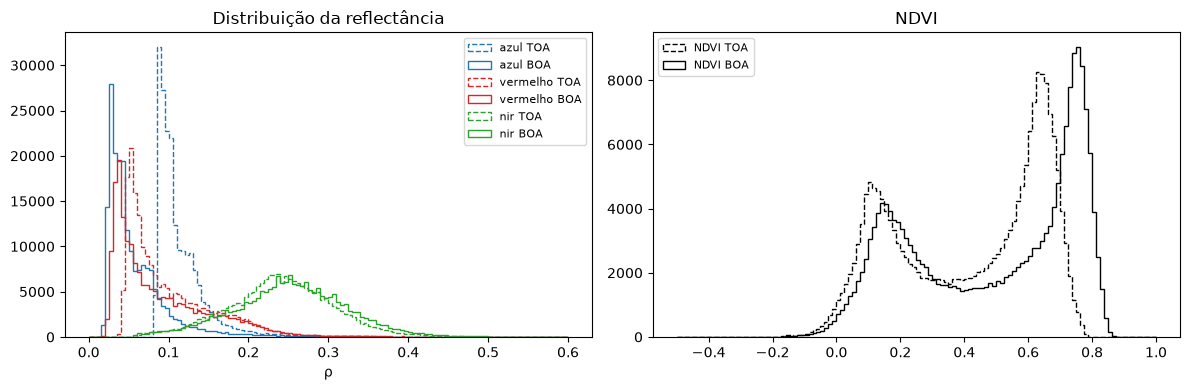

In [9]:
#| label: fig-toa-boa
#| fig-cap: "Distribuição da reflectância e do NDVI, antes e depois da correção atmosférica."
if NIVEL == "boa":
    idx = np.flatnonzero(valido.ravel())
    idx = np.random.default_rng(42).choice(idx, min(200_000, idx.size), replace=False)

    print(f"{'banda':<10} {'TOA p50':>10} {'BOA p50':>10} {'variação':>12}")
    for n, nome in ac.BANDAS_NATIVAS.items():
        a = float(np.percentile(toa[n].ravel()[idx], 50))
        b = float(np.percentile(refl[nome].ravel()[idx], 50))
        print(f"{nome:<10} {a:>10.4f} {b:>10.4f} {b - a:>+12.4f}")

    def ndvi_de(r, nir):
        den = nir + r
        return (nir - r) / np.where(den > 1e-6, den, np.nan)

    n_toa = ndvi_de(toa[3].ravel()[idx], toa[4].ravel()[idx])
    n_boa = ndvi_de(refl["vermelho"].ravel()[idx], refl["nir"].ravel()[idx])
    print(f"\nNDVI mediano: TOA {np.nanmedian(n_toa):.4f} -> BOA {np.nanmedian(n_boa):.4f}")

    fig, ax = plt.subplots(1, 2, figsize=(12, 4))
    for nome, cor in [("azul", "tab:blue"), ("vermelho", "tab:red"), ("nir", "tab:green")]:
        n = [k for k, v in ac.BANDAS_NATIVAS.items() if v == nome][0]
        ax[0].hist(toa[n].ravel()[idx], bins=120, range=(0, 0.6), histtype="step",
                   label=f"{nome} TOA", color=cor, linestyle="--")
        ax[0].hist(refl[nome].ravel()[idx], bins=120, range=(0, 0.6), histtype="step",
                   label=f"{nome} BOA", color=cor)
    ax[0].set_title("Distribuição da reflectância"); ax[0].set_xlabel("ρ"); ax[0].legend(fontsize=8)
    ax[1].hist(n_toa[np.isfinite(n_toa)], bins=120, range=(-0.5, 1), histtype="step",
               label="NDVI TOA", linestyle="--", color="k")
    ax[1].hist(n_boa[np.isfinite(n_boa)], bins=120, range=(-0.5, 1), histtype="step",
               label="NDVI BOA", color="k")
    ax[1].set_title("NDVI"); ax[1].legend(fontsize=8)
    plt.tight_layout(); plt.show()
else:
    print("Nível TOA — sem comparação a fazer.")

### 4.3 Reflectância negativa: o que é normal e o que é sintoma

Se você olhar as estatísticas do resultado ainda em ponto flutuante, vai encontrar
**valores negativos**. Isso assusta na primeira vez, então vale separar três coisas.

**O que é ruído.** Reflectância de superfície levemente negativa aparece em qualquer correção
atmosférica: sobre água, sombra profunda e asfalto molhado o sinal real é tão baixo que o erro
do modelo — alguns milésimos — atravessa o zero. Os produtos operacionais convivem com isso; a
faixa **válida** do produto de reflectância de superfície do Landsat Collection 2 (USGS) vai de
**−0,2 a 1,6** justamente por causa dessa cauda.

**O que é sintoma.** Se a **mediana** de uma banda estiver negativa, ou se **mais de uns 5%**
dos pixels de uma banda saírem abaixo de zero, não é ruído: é correção demais, quase sempre
**AOD alto demais**. Volte na seção 4.1.

**O que grava no arquivo.** Reflectância negativa não existe fisicamente, então o produto sai
com **piso em 0** (`PISO_REFLECTANCIA`, seção 0). Repare na ordem: o diagnóstico abaixo roda
sobre os valores em ponto flutuante, **antes** do piso. Ou seja, o piso não apaga o sintoma —
ele só impede que o `.tif` carregue um valor impossível. E como o `NODATA` é −9999, o pixel
ceifado continua sendo **dado válido**, com valor 0.

::: {.callout-note}
## Por que 0 e não −0,2

Um piso em zero introduz um viés positivo nos alvos escuros. Nesta cena, medido: **+1 na escala
de 10.000**, ou seja, 0,0001 de reflectância — e só nos pixels ceifados, que são menos de 2% da
banda azul. É pequeno o bastante para não valer a pena guardar um valor que nenhum software de
SIG vai saber interpretar.

Se o seu trabalho precisa da cauda negativa preservada (comparação com produtos Landsat C2, por
exemplo), ponha `PISO_REFLECTANCIA = -0.2` e declare isso no método.
:::

A tabela abaixo separa ruído de sintoma. Ela é o teste que eu faria antes de aceitar qualquer
produto BOA.

In [10]:
#| label: tbl-negativos
def diagnostico_negativos(refl_por_nome, valido):
    print(f"{'banda':<10}{'% < 0':>10}{'p1':>10}{'mediana':>10}{'mínimo':>10}")
    fora = {}
    for nome, arr in refl_por_nome.items():
        v = arr[valido]
        fora[nome] = (float((v < 0).mean()), float(np.percentile(v, 1)),
                      float(np.median(v)), float(v.min()))
        print(f"{nome:<10}{fora[nome][0]:>9.2%}{fora[nome][1]:>10.4f}"
              f"{fora[nome][2]:>10.4f}{fora[nome][3]:>10.4f}")
    return fora


neg = diagnostico_negativos(refl, valido)

pior = max(neg.values(), key=lambda x: x[0])
if any(v[2] < 0 for v in neg.values()):
    print("\n> Alguma banda tem MEDIANA negativa. Isso é correção demais, não ruído:")
    print("  reveja o AOD (seção 4.1) antes de seguir.")
elif pior[0] > 0.05:
    print(f"\n> {pior[0]:.1%} dos pixels de uma banda saíram negativos — acima do que se")
    print("  explica por alvo escuro. O AOD do arquivo provavelmente está alto demais.")
else:
    print("\n> Negativos restritos à cauda escura: comportamento esperado de um produto BOA.")

banda          % < 0        p1   mediana    mínimo
azul          0.00%    0.0206    0.0437   -0.0069
verde         0.00%    0.0296    0.0692   -0.0028
vermelho      0.00%    0.0248    0.0669   -0.0077
nir           0.00%    0.0813    0.2536    0.0318

> Negativos restritos à cauda escura: comportamento esperado de um produto BOA.


## 5. Gravando o composto RGBN de 8 m

Saída em `int16` com a reflectância multiplicada por **10.000** — a mesma escala do produto
Sentinel-2 L2A, o que evita conversão na Aula 03. O nodata vai como `-9999`, e não como 0,
porque zero agora é um valor de reflectância legítimo.

A ordem física passa a ser **RGBN** (vermelho, verde, azul, NIR), diferente da ordem nativa do
CBERS (azul, verde, vermelho, NIR). E os nomes das bandas são **gravados dentro do arquivo**:
as aulas seguintes leem a ordem do metadado em vez de assumir. Isso não é preciosismo — uma
troca silenciosa de R por B não quebra nada, só faz todas as métricas saírem erradas.

In [11]:
ORDEM_SAIDA = ac.ORDEM_SAIDA        # [3, 2, 1, 4] = vermelho, verde, azul, NIR (numeração nativa)
NOMES = ac.NOMES_SAIDA              # ["red", "green", "blue", "nir"]

rgbcomp = P["interim"] / f"rgbcomp_{DATA}_{NIVEL}.tif"
perfil.update(count=4, dtype="int16", nodata=NODATA, compress="deflate", predictor=2,
              tiled=True, blockxsize=512, blockysize=512, BIGTIFF="IF_SAFER")

PISO_ESC, TETO_ESC = PISO_REFLECTANCIA * ESCALA, TETO_REFLECTANCIA * ESCALA
cortados = {}

with rasterio.open(rgbcomp, "w", **perfil) as dst:
    for i, n in enumerate(ORDEM_SAIDA, start=1):
        arr = refl[ac.BANDAS_NATIVAS[n]]
        fora = (arr < PISO_REFLECTANCIA) | (arr > TETO_REFLECTANCIA)
        cortados[NOMES[i - 1]] = int(fora[valido].sum())
        esc = np.clip(np.rint(arr * ESCALA), PISO_ESC, TETO_ESC)
        dst.write(np.where(valido, esc, NODATA).astype("int16"), i)
        dst.set_band_description(i, NOMES[i - 1])
    dst.colorinterp = [ColorInterp.red, ColorInterp.green, ColorInterp.blue,
                       ColorInterp.undefined]
    dst.update_tags(ORDEM_BANDAS="RGBN", NIVEL=NIVEL.upper(), FATOR_ESCALA=str(ESCALA),
                    CENA=CENA_ID, DATA=meta["data"])

# procedência: o que foi usado para gerar este arquivo, em texto, ao lado dele
params = {
    "gerado_em": datetime.now().isoformat(timespec="seconds"),
    "aula": "01", "cena": CENA_ID, "data_cena": meta["data"], "nivel": NIVEL,
    "bbox_4326": AOI_BBOX,
    "convencao_coeficiente": "L = DN * absoluteCalibrationCoefficient (offset zero)",
    "coeficientes_calibracao": meta["coeficientes"],
    "esun": esun, "distancia_terra_sol_ua": d, "cos_zenite_solar": cos_z,
    "elevacao_solar": meta["elevacao_solar"],
    "coeficientes_6s": coefs_6s or None, "atmosfera": atm,
    "aod_ajustado_por_alvo_escuro": bool(NIVEL == "boa" and AJUSTAR_AOD),
    "faixa_reflectancia": [PISO_REFLECTANCIA, TETO_REFLECTANCIA],
    "negativos_por_banda": {k: {"frac": v[0], "p1": v[1], "mediana": v[2], "min": v[3]}
                            for k, v in neg.items()},
    "ordem_bandas": "RGBN", "fator_escala": ESCALA, "nodata": NODATA,
    "regra_nodata": "zero em QUALQUER banda MS",
    "px_nodata": int(zeros.sum()), "frac_nodata": float(zeros.mean()),
}
rgbcomp.with_suffix(".params.json").write_text(
    json.dumps(params, indent=2, ensure_ascii=False), encoding="utf-8")

print(f"Escrito: {rgbcomp}")
print(f"Params : {rgbcomp.with_suffix('.params.json')}")
print(f"Pixels cortados na faixa [{PISO_REFLECTANCIA}, {TETO_REFLECTANCIA}]: {cortados}")

Escrito: data\interim\rgbcomp_20260301_boa.tif
Params : data\interim\rgbcomp_20260301_boa.params.json
Pixels cortados na faixa [0.0, 1.6]: {'red': 1, 'green': 2, 'blue': 3, 'nir': 0}


## 6. Alinhando a multiespectral com a pancromática

A Aula 00 recortou cada banda calculando a janela **na grade dela**: a MS arredonda em passos
de 8 m, a PAN em passos de 2 m. As duas cobrem a mesma AOI, mas podem terminar deslocadas em
alguns metros e com uma razão que não é exatamente 4:1.

O Gram-Schmidt precisa de razão inteira e origens coincidentes. Sem isso, a fusão introduz um
deslocamento subpixel que se propaga por tudo — inclusive pelo coregistro da Aula 03, que é
justamente onde ele apareceria como um erro que você não sabe de onde veio.

A função abaixo resolve os dois problemas de uma vez: recorta as duas imagens à extensão comum
encaixada na grade de 8 m e reamostra a PAN para a grade derivada dessa, com fator exato de 4.

In [13]:
ms, pan, t_ms, t_pan, crs, nod_ms, FATOR = ac.alinhar_ms_pan(
    rgbcomp, arquivos["BAND0"])

print(f"\nfator MS/PAN     : {FATOR}")
print(f"origem MS  (x, y): {t_ms.c:.1f}, {t_ms.f:.1f}")
print(f"origem PAN (x, y): {t_pan.c:.1f}, {t_pan.f:.1f}   (devem ser iguais)")
print(f"CRS              : {crs}")

MS  alinhado: 1286 x 1314 px @ 8 m
PAN alinhada: 5144 x 5256 px @ 2 m

fator MS/PAN     : 4
origem MS  (x, y): 232788.0, 7523622.0
origem PAN (x, y): 232788.0, 7523622.0   (devem ser iguais)
CRS              : EPSG:32723


## 7. A fusão Gram-Schmidt

O Gram-Schmidt é um método de **substituição de componente**. A ideia:

1. simula uma pancromática a partir das bandas multiespectrais, $I$;
2. casa **média e desvio** da pancromática real com os dessa simulada;
3. calcula a diferença $\Delta = PAN' - I$, que é o **detalhe espacial** que só a PAN tem;
4. devolve esse detalhe a cada banda com um ganho próprio,
   $MS_i^{fus} = MS_i + g_i \Delta$, onde $g_i = \mathrm{cov}(MS_i, I) / \mathrm{var}(I)$.

O passo 2 é o que faz o método ser **indiferente à escala da PAN**: como o casamento absorve
qualquer fator multiplicativo, tanto faz a pancromática estar em DN ou em reflectância. Isso
**não** valeria para Brovey ou IHS, onde a escala da PAN propaga para a saída.

### Como simular a pancromática — e por que isso decide tudo

A forma clássica do passo 1 é uma soma de **pesos fixos**, $I = \sum_i w_i MS_i$, com
R 0,166 | G 0,167 | B 0,167 | NIR 0,5 — os padrões genéricos do ArcGIS Pro, já que o CBERS-4A
não consta na lista de sensores da ferramenta.

O problema é que esses pesos são um chute sobre a resposta espectral do sensor. Com 0,5 no NIR,
$I$ fica dominado pelo infravermelho e **não se parece com a PAN de verdade**. Aí o passo 3
degringola: $\Delta$ deixa de ser só detalhe de alta frequência e passa a carregar o
descasamento espectral inteiro. Esse descasamento é injetado nas bandas e empurra os alvos
escuros — água, sombra — para baixo de zero. Nesta cena, com pesos fixos, o desvio de $\Delta$
dá **233** na escala de 10.000; a banda azul sai com **4,0% de pixels negativos**.

A correção é a de @aiazzi_improving_2007: degradar a PAN para a grade de 8 m e achar **por
mínimos quadrados** os coeficientes que melhor reproduzem a PAN a partir das próprias bandas MS,

$$I = a_0 + \sum_i a_i \, MS_i .$$

É o método conhecido como **GSA** (*Gram-Schmidt Adaptive*). Com ele o desvio de $\Delta$ cai
para **29** — oito vezes menor —, os negativos do azul caem para **1,9%**, e a consistência
espectral melhora em todas as bandas (o RMSE entre a média 4×4 da fusão e o MS original cai de
123 para 102 no azul, e de 244 para 140 no NIR).

O que sobra de negativo depois disso é a cauda escura mesmo, e é o piso da seção 0 que resolve.

> Esta implementação em NumPy substitui o `CreatePansharpenedRasterDataset` do ArcGIS Pro, que
> exige licença e só roda no interpretador do próprio ArcGIS. Note que a ferramenta da ESRI
> grava em `uint16` com `NoData = 0`: lá o negativo é ceifado em zero **e some**, virando
> buraco na imagem. Aqui ele é ceifado em zero e **continua valendo como dado**.

In [14]:
# ---- MS reamostrada para a grade da PAN ----
ms_f = ms.astype("float32")
valido_ms = ~np.all(ms == (nod_ms if nod_ms is not None else NODATA), axis=0)
ms_f[:, ~valido_ms] = np.nan

alt, larg = pan.shape
ms_up = np.empty((4, alt, larg), dtype="float32")
for i in range(4):
    reproject(source=np.nan_to_num(ms_f[i], nan=0.0), destination=ms_up[i],
              src_transform=t_ms, src_crs=crs, dst_transform=t_pan, dst_crs=crs,
              resampling=Resampling.cubic)

val_up = np.empty((alt, larg), dtype="float32")
reproject(source=valido_ms.astype("float32"), destination=val_up,
          src_transform=t_ms, src_crs=crs, dst_transform=t_pan, dst_crs=crs,
          resampling=Resampling.bilinear)
valido_fus = (val_up > 0.999) & (pan > 0)

print(f"grade da fusão: {larg} x {alt} px @ 2 m")
print(f"pixels válidos: {valido_fus.mean() * 100:.2f}%")

grade da fusão: 5144 x 5256 px @ 2 m
pixels válidos: 100.00%


In [15]:
def intensidade_por_regressao(ms_lr, pan, valido_lr, fator):
    """Coeficientes da pancromática simulada, estimados por regressão (GSA).

    ms_lr     : (4, h, w) MS na resolução NATIVA (8 m)
    pan       : (h*fator, w*fator) pancromática na grade fina (2 m)
    valido_lr : (h, w) máscara de pixel válido do MS

    Degrada a PAN para a grade do MS (média de blocos fator x fator) e resolve
    por mínimos quadrados  PAN_degradada ~ a0 + sum(a_i * MS_i).
    """
    n_bandas, h, w = ms_lr.shape
    pan_lp = (pan[:h * fator, :w * fator]
              .reshape(h, fator, w, fator).mean(axis=(1, 3)))
    m = valido_lr & (pan_lp > 0)
    X = np.column_stack([ms_lr[i][m].astype("float64") for i in range(n_bandas)]
                        + [np.ones(int(m.sum()))])
    y = pan_lp[m].astype("float64")
    alpha, *_ = np.linalg.lstsq(X, y, rcond=None)
    r2 = float(1.0 - (y - X @ alpha).var() / max(y.var(), 1e-12))
    return alpha, r2, pan_lp


def gram_schmidt(ms_up, pan, valido, alpha=None, pesos=None):
    """Fusão por substituição de componente (Gram-Schmidt / GSA).

    ms_up : (4, h, w) já na grade da PAN, ordem RGBN
    pan   : (h, w)
    alpha : coeficientes de `intensidade_por_regressao` (modo GSA).
            Sem eles, cai nos pesos fixos — o Gram-Schmidt clássico.
    """
    if alpha is not None:
        a = np.asarray(alpha, dtype="float32")
        I = np.tensordot(a[:-1], ms_up, axes=(0, 0)) + a[-1]
    else:
        w = np.array([pesos[n] for n in NOMES], dtype="float32")
        w = w / w.sum()
        I = np.tensordot(w, ms_up, axes=(0, 0))

    # estatísticas numa amostra: com dezenas de milhões de pixels, média,
    # desvio e covariância convergem muito antes de usar todos eles
    idx = np.flatnonzero(valido.ravel())
    if idx.size > 2_000_000:
        idx = np.random.default_rng(42).choice(idx, 2_000_000, replace=False)
    pa = pan.ravel()[idx].astype("float64")
    ia = I.ravel()[idx].astype("float64")

    pan_ajustada = (pan - pa.mean()) * (ia.std() / max(pa.std(), 1e-9)) + ia.mean()
    delta = pan_ajustada - I

    ia_c = ia - ia.mean()
    var_I = max(float(ia.var()), 1e-9)
    saida = np.empty_like(ms_up)
    ganhos = {}
    for i, nome in enumerate(NOMES):
        bi = ms_up[i].ravel()[idx].astype("float64")
        g = float(np.dot(bi - bi.mean(), ia_c) / ia_c.size) / var_I
        ganhos[nome] = g
        saida[i] = ms_up[i] + g * delta
    return saida, ganhos, delta


# ---- 1. a intensidade simulada, por regressão (GSA) -------------------------
alpha, r2_pan, _ = intensidade_por_regressao(
    ms.astype("float32"), pan, valido_ms, FATOR)

print("I = a0 + soma(a_i * MS_i), por mínimos quadrados contra a PAN degradada:")
for nome, a in zip(NOMES, alpha[:4]):
    print(f"  a_{nome:<6} {a:+.5f}")
print(f"  a0      {alpha[4]:+.3f}")
print(f"  R² da regressão: {r2_pan:.4f}"
      "   (perto de 1 = a MS explica bem a PAN; longe = descasamento espectral)")

# ---- 2. o quanto isso muda o detalhe injetado ------------------------------
# Comparação barata, só na amostra: qual seria o desvio de delta com os pesos
# fixos do Gram-Schmidt clássico. É esse número que produz os negativos.
_idx = np.flatnonzero(valido_fus.ravel())
if _idx.size > 500_000:
    _idx = np.random.default_rng(7).choice(_idx, 500_000, replace=False)
_pa = pan.ravel()[_idx].astype("float64")
_w = np.array([ac.PESOS_GS[n] for n in NOMES], dtype="float64")
_w = _w / _w.sum()
_I_fixo = sum(_w[i] * ms_up[i].ravel()[_idx].astype("float64") for i in range(4))
_I_reg = (sum(alpha[i] * ms_up[i].ravel()[_idx].astype("float64") for i in range(4))
          + alpha[4])
for rotulo, _I in (("pesos fixos", _I_fixo), ("regressão (GSA)", _I_reg)):
    _paj = (_pa - _pa.mean()) * (_I.std() / max(_pa.std(), 1e-9)) + _I.mean()
    print(f"  desvio de delta com {rotulo:<16}: {(_paj - _I).std():8.1f}")
del _I_fixo, _I_reg, _pa, _idx

# ---- 3. a fusão ------------------------------------------------------------
fus, ganhos, delta_fus = gram_schmidt(ms_up, pan, valido_fus, alpha=alpha)
print("\nganho por banda (cov(MS, I) / var(I)):")
for nome, g in ganhos.items():
    print(f"  {nome:<6} {g:.4f}")

I = a0 + soma(a_i * MS_i), por mínimos quadrados contra a PAN degradada:
  a_red    +0.05471
  a_green  +0.03846
  a_blue   +0.01387
  a_nir    +0.05685
  a0      +49.342
  R² da regressão: 0.9423   (perto de 1 = a MS explica bem a PAN; longe = descasamento espectral)
  desvio de delta com pesos fixos     :    226.0
  desvio de delta com regressão (GSA) :     29.4

ganho por banda (cov(MS, I) / var(I)):
  red    6.7825
  green  5.6017
  blue   4.9527
  nir    6.0657


In [16]:
pansharp = P["interim"] / f"pansharpening_{DATA}_{NIVEL}.tif"
perfil_fus = dict(driver="GTiff", dtype="int16", count=4, height=alt, width=larg,
                  transform=t_pan, crs=crs, nodata=NODATA, compress="deflate",
                  predictor=2, tiled=True, blockxsize=512, blockysize=512,
                  BIGTIFF="IF_SAFER", interleave="band")

# Mesmo com a intensidade por regressão sobra uma cauda abaixo de zero: o
# detalhe injetado é aditivo, e onde a banda já vale pouco (azul sobre água e
# sombra) a soma atravessa o zero. Isso NÃO é reflectância — é ruído em torno de
# zero. Medimos antes e gravamos com o piso.
print(f"{'banda':<8}{'% < 0':>9}{'mínimo':>10}{'mediana dos negativos':>24}")
neg_fus, ceifados = {}, {}
for i, nome in enumerate(NOMES):
    v = fus[i][valido_fus]
    negativos = v[v < PISO_ESC]
    neg_fus[nome] = float((v < 0).mean())
    ceifados[nome] = int(negativos.size)
    med = float(np.median(negativos)) / ESCALA if negativos.size else 0.0
    print(f"{nome:<8}{neg_fus[nome]:>8.2%}{v.min() / ESCALA:>10.4f}{med:>24.4f}")
print(f"\npiso aplicado em {PISO_REFLECTANCIA:g} — os pixels acima continuam intactos,")
print("e o pixel ceifado vale 0 e segue VÁLIDO (o nodata é -9999, outro valor).")

with rasterio.open(pansharp, "w", **perfil_fus) as dst:
    for i in range(4):
        b = np.clip(np.rint(fus[i]), PISO_ESC, TETO_ESC)
        dst.write(np.where(valido_fus, b, NODATA).astype("int16"), i + 1)
        dst.set_band_description(i + 1, NOMES[i])          # carimbo da ordem
    dst.update_tags(ORDEM_BANDAS="RGBN", NIVEL=NIVEL.upper(), FATOR_ESCALA=str(ESCALA),
                    METODO="Gram-Schmidt (GSA, intensidade por regressao)",
                    CENA=CENA_ID,
                    FAIXA_REFLECTANCIA=f"[{PISO_REFLECTANCIA}, {TETO_REFLECTANCIA}]")

params.update({"etapa": "pansharpening",
               "metodo": "Gram-Schmidt (GSA)",
               "intensidade": "regressao multivariada da PAN degradada sobre as bandas MS",
               "intensidade_coeficientes": dict(zip(NOMES + ["const"],
                                                    [float(a) for a in alpha])),
               "intensidade_r2": float(r2_pan),
               "pesos_gs_classico_nao_usados": ac.PESOS_GS,
               "ganhos": ganhos,
               "negativos_apos_fusao": neg_fus,
               "px_ceifados_no_piso": ceifados,
               "entrada_ms": str(rgbcomp), "entrada_pan": str(arquivos["BAND0"]),
               "saida": str(pansharp)})
pansharp.with_suffix(".params.json").write_text(
    json.dumps(params, indent=2, ensure_ascii=False), encoding="utf-8")

with rasterio.open(pansharp) as src:
    print(f"\nEscrito: {pansharp}")
    print(f"  {src.width} x {src.height} px @ {src.res[0]:g} m | {src.dtypes[0]}")
    print(f"  bandas  : {src.descriptions}")
    print(f"  tamanho : {pansharp.stat().st_size / 1024**2:.1f} MB")

banda       % < 0    mínimo   mediana dos negativos
red        0.50%   -0.0594                 -0.0056
green      0.04%   -0.0326                 -0.0030
blue       0.35%   -0.0843                 -0.0039
nir        0.00%    0.0112                  0.0000

piso aplicado em 0 — os pixels acima continuam intactos,
e o pixel ceifado vale 0 e segue VÁLIDO (o nodata é -9999, outro valor).

Escrito: data\interim\pansharpening_20260301_boa.tif
  5144 x 5256 px @ 2 m | int16
  bandas  : ('red', 'green', 'blue', 'nir')
  tamanho : 145.0 MB


## 8. Conferindo o resultado

Duas coisas para olhar: se a fusão **ganhou detalhe** sem inventar cor, e se a cena tem
**nuvem** — porque é ela que a Aula 02 vai detectar.

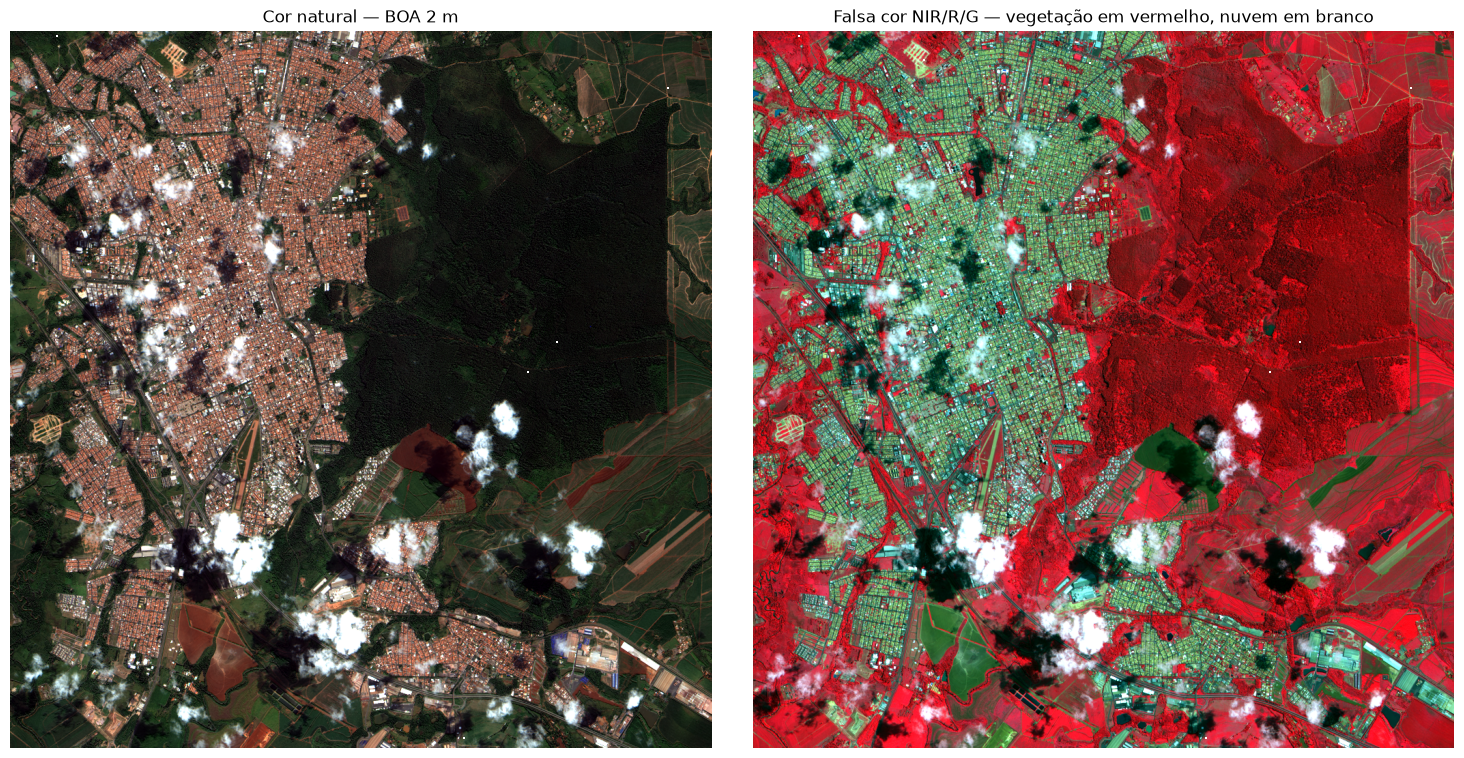

In [17]:
#| label: fig-fusao
#| fig-cap: "Cena fusionada em 2 m: cor natural e falsa cor NIR/R/G."
# visão geral, em resolução reduzida
with rasterio.open(pansharp) as src:
    fator = max(1, src.width // 900)
    forma = (3, src.height // fator, src.width // fator)
    vis = src.read((1, 2, 3), out_shape=forma,
                   resampling=Resampling.average).astype("float32")
    vis_nir = src.read(4, out_shape=forma[1:],
                       resampling=Resampling.average).astype("float32")
vis[vis == NODATA] = np.nan

fig, ax = plt.subplots(1, 2, figsize=(15, 7.5))
ax[0].imshow(np.dstack([ac.stretch(vis[0]), ac.stretch(vis[1]), ac.stretch(vis[2])]))
ax[0].set_title(f"Cor natural — {NIVEL.upper()} 2 m")
ax[1].imshow(np.dstack([ac.stretch(vis_nir), ac.stretch(vis[0]), ac.stretch(vis[1])]))
ax[1].set_title("Falsa cor NIR/R/G — vegetação em vermelho, nuvem em branco")
for a in ax:
    a.axis("off")
plt.tight_layout(); plt.show()

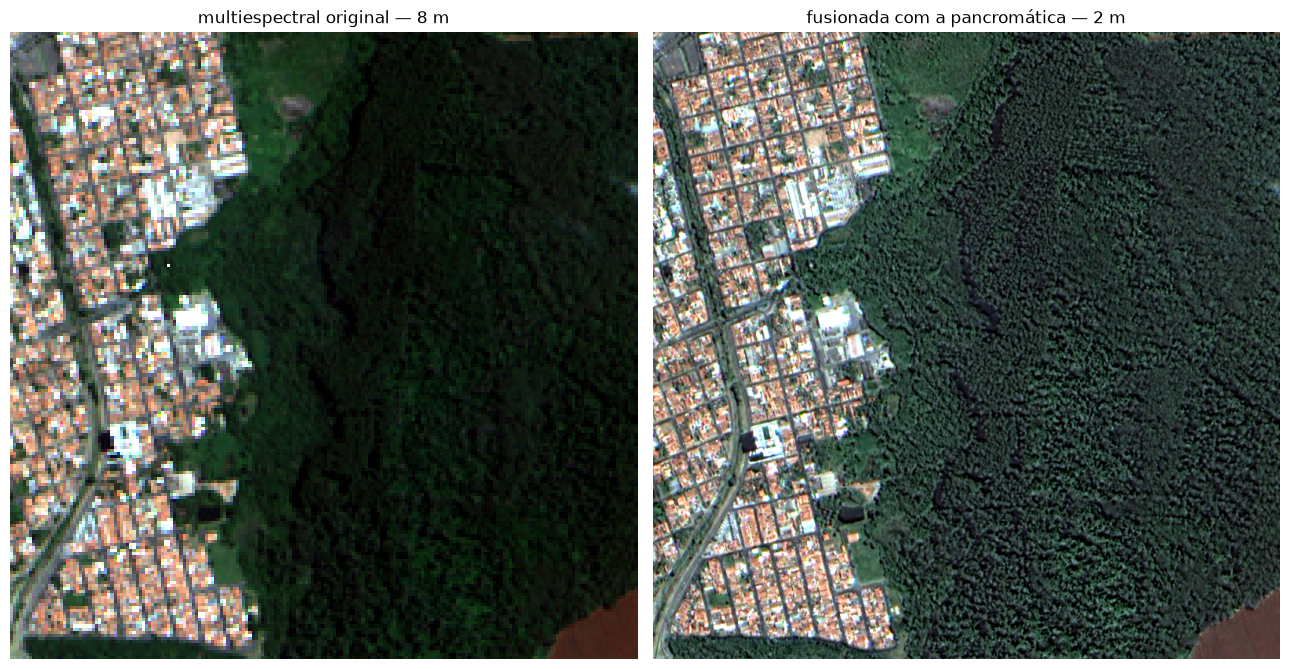

In [18]:
#| label: fig-fusao-zoom
#| fig-cap: "O mesmo trecho antes (8 m) e depois (2 m) da fusão Gram-Schmidt."
# zoom: 8 m antes da fusão x 2 m depois, no mesmo pedaço de terreno
lado = 200                                   # em pixels de 8 m -> 1,6 km
r0 = max(0, ms.shape[1] // 2 - lado // 2)
c0 = max(0, ms.shape[2] // 2 - lado // 2)

antes = ms[:3, r0:r0 + lado, c0:c0 + lado].astype("float32")
antes[antes == NODATA] = np.nan
depois = fus[:3, r0 * FATOR:(r0 + lado) * FATOR, c0 * FATOR:(c0 + lado) * FATOR]

fig, ax = plt.subplots(1, 2, figsize=(13, 6.6))
ax[0].imshow(np.dstack([ac.stretch(b) for b in antes]))
ax[0].set_title("multiespectral original — 8 m")
ax[1].imshow(np.dstack([ac.stretch(b) for b in depois]))
ax[1].set_title("fusionada com a pancromática — 2 m")
for a in ax:
    a.axis("off")
plt.tight_layout(); plt.show()

## O que ficou pronto

```
data/interim/rgbcomp_<DATA>_<nivel>.tif          8 m, RGBN, reflectância x10000
data/interim/pansharpening_<DATA>_<nivel>.tif    2 m, RGBN, reflectância x10000   <- produto da aula
data/interim/*.params.json                       o que foi usado para gerar cada um
```

Na **Aula 02** esse arquivo de 2 m entra no OmniCloudMask, que separa nuvem densa, nuvem fina e
sombra de nuvem. Na **Aula 03** os pixels marcados viram lacunas a serem preenchidas com
Sentinel-2 super-resolvido.

## Referências

- Pinto, C. T. et al. (2016). *Uncertainty Evaluation for In-Flight Radiometric Calibration of CBERS-4 Multispectral Sensors*. Remote Sensing, 8(5), 405.
- CRESDA. *Irradiância solar equivalente no topo da atmosfera dos sensores civis de observação terrestre* (Anexo 4), rev. 2024-12-22.
- Vermote, E. F. et al. (1997). *Second Simulation of the Satellite Signal in the Solar Spectrum, 6S*. IEEE TGRS, 35(3), 675–686.
- Laben, C. A.; Brower, B. V. (2000). *Process for enhancing the spatial resolution of multispectral imagery using pan-sharpening*. US Patent 6.011.875.
- Aiazzi, B. et al. (2007). *Improving component substitution pansharpening through multivariate regression of MS+Pan data*. IEEE TGRS, 45(10), 3230–3239.
- [Py6S](https://py6s.readthedocs.io) · [rasterio](https://rasterio.readthedocs.io)